In [1]:
from c3s_lib import *
import requests
import urllib.parse
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import json
import geopandas as gpd
import rasterio
from rasterio import features
from shapely.geometry import shape, Polygon, mapping, MultiPolygon, GeometryCollection
from shapely.vectorized import contains # replace with below
from shapely import contains_xy
import xarray as xr
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from shapely.ops import unary_union
from datetime import datetime, timedelta
import pandas as pd
import contextily as ctx
import math
import regionmask
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import cmocean
import base64
from io import BytesIO
import contextily as ctx
from typing import Union, Literal
import os


In [2]:
#Api key used for the DataClient, replace with your own API key from the C3S Climate Data Store
your_api_key = '98256e82-4de4-4cc1-8087-faebb5c2e4ae'

In [3]:
bbox = (-110, 18, -95, 30) # Bounding box (-lon, -lat, +lon, +lat)
event_date = datetime(2024, 6, 7)
event_start_date = event_date - timedelta(days=14)

In [4]:
climatology_1951_date = datetime(1951, 1, 1) # should be 1950 when beacon is updated
climatology_gdf_1950_event = DataClient(your_api_key, beacon_cache_url='https://beacon-development.maris.nl').temperature_2m_mean(bbox, (climatology_1951_date, event_date))
climatology_gdf_1950_event = climatology_gdf_1950_event.sort_values(by='valid_time')

2025-09-04 15:53:34,424 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


Connected to: https://beacon-development.maris.nl/ server successfully
Connected to: https://beacon-development.maris.nl/ server successfully
Fetching data from beacon cache...
Beacon Bbox: (250.0, 18, 265.0, 30)
Running query: {"from": "era5_daily_mean_2m_temperature", "select": [{"column": "longitude", "alias": null}, {"column": "latitude", "alias": null}, {"column": "valid_time", "alias": null}, {"column": "t2m", "alias": null}], "filters": [{"and": [{"column": "longitude", "gt_eq": 250.0, "lt_eq": null}, {"column": "longitude", "gt_eq": null, "lt_eq": 265.0}, {"column": "latitude", "gt_eq": 18, "lt_eq": null}, {"column": "latitude", "gt_eq": null, "lt_eq": 30}]}, {"column": "valid_time", "gt_eq": "1951-01-01T00:00:00.000000", "lt_eq": "2024-06-07T00:00:00.000000"}], "output": {"format": "parquet"}}
Beacon cache covers time range: 1951-01-01 00:00:00 - 2024-06-07 00:00:00


In [5]:
climatology_1991_date = datetime(1991, 1, 1)
climatology_2020_date = datetime(2020, 12, 31)

event_gdf = climatology_gdf_1950_event[(climatology_gdf_1950_event['valid_time'] >= event_start_date) & (climatology_gdf_1950_event['valid_time'] <= event_date)]
climatology_gdf_1991_2020 = climatology_gdf_1950_event[(climatology_gdf_1950_event['valid_time'] >= climatology_1991_date) & (climatology_gdf_1950_event['valid_time'] <= climatology_2020_date)]

c:\Python310\lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


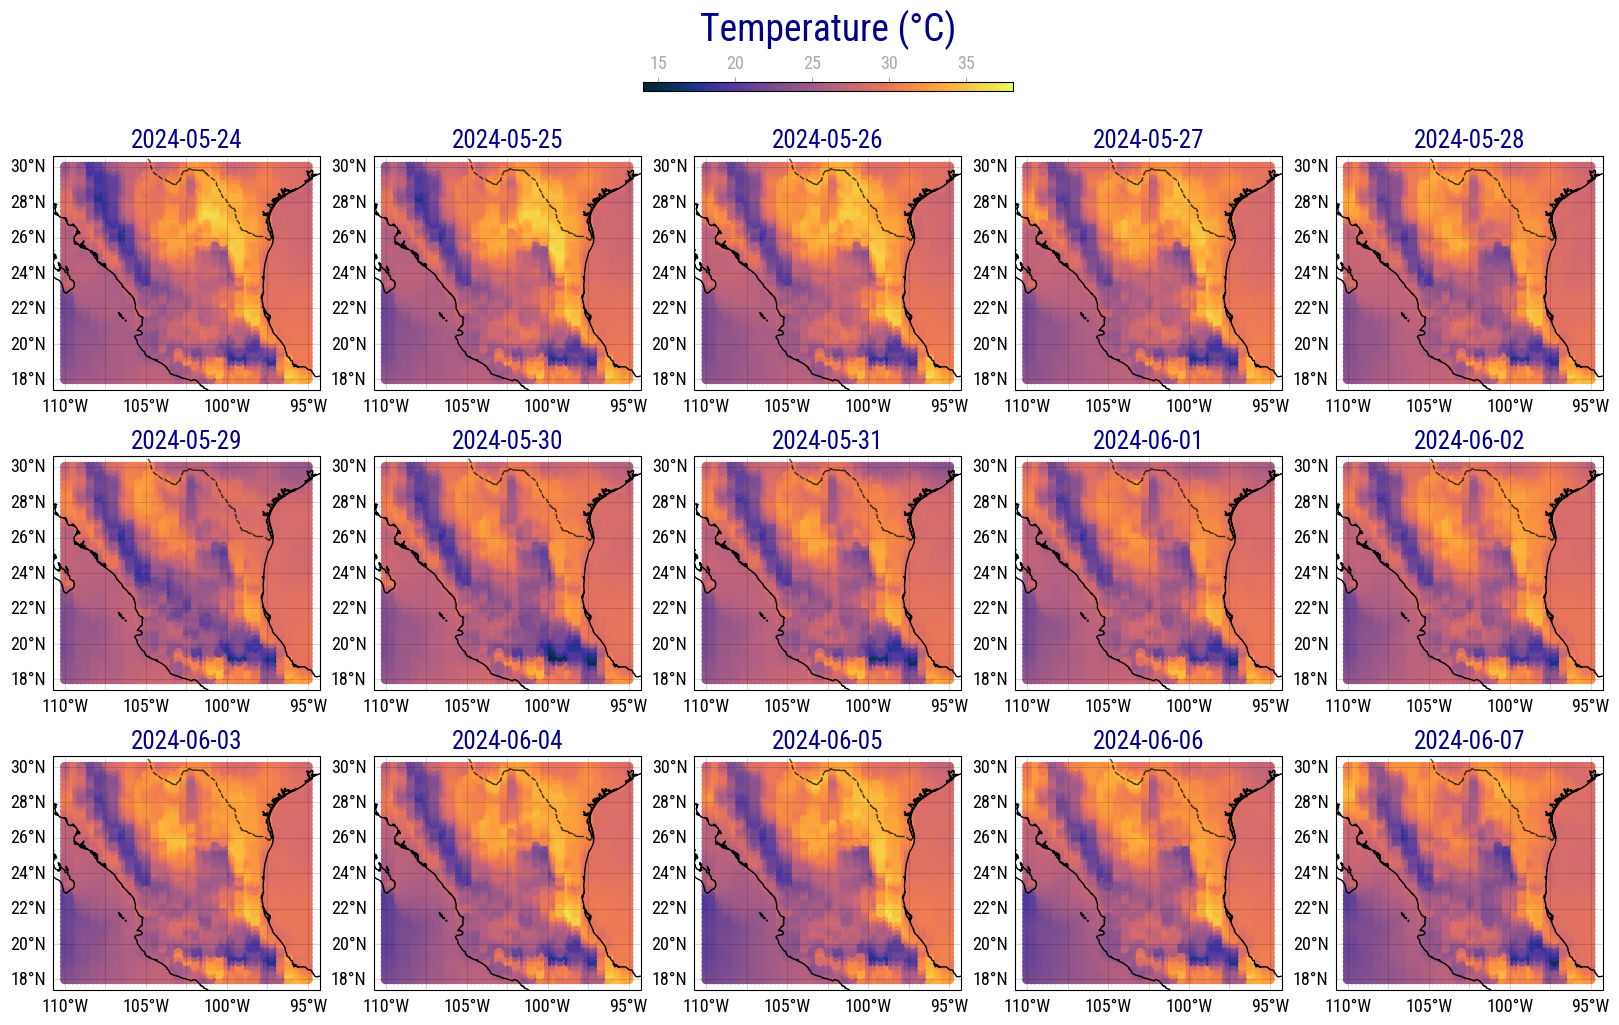

In [6]:
fig, axes = subplot_gdf(
    event_gdf,
    datetime_col='valid_time',
    value_col='t2m',
    ncols=5,
    cmap=cmocean.cm.thermal,
    legend_title='Temperature (°C)'
)

In [7]:
def ddsliding_stat_by_dayofyear(data, pad=15):
    """
    Parameters:
    -----------
    data : ...
    pad : int
        Number of days on either side to include in the window (default: 15 → 30-day window)

    Returns:
    --------
    """
    # Ensure 'time' column is datetime
    data['valid_time'] = pd.to_datetime(data['valid_time'])

    # Boolean mask: keep all rows NOT Feb 29
    mask = ~((data['valid_time'].dt.month == 2) & (data['valid_time'].dt.day == 29))

    # Apply mask
    data = data[mask]

    days = np.arange(1, 366)  # Days of year

    data['doy'] = data['valid_time'].dt.dayofyear

    data['longitude'] = data.geometry.x
    data['latitude'] = data.geometry.y

    result_list = []

    for day in days:
        # Build ±pad-day window (cyclically)
        window_days = [(day + offset - 1) % 365 + 1 for offset in range(-pad, pad + 1)]
        
        window_data = data[data['doy'].isin(window_days)]

        # Compute mean at each location
        daily_mean = (
            window_data.groupby(['longitude', 'latitude'])['t2m']
            .mean()
            .reset_index()
        )
        
        daily_mean['doy'] = day
        result_list.append(daily_mean)
        doy_mean_gdf = pd.concat(result_list, ignore_index=True)

    return doy_mean_gdf

In [8]:
# calculate the 30-day smoothed climatology for 1991-2020 for calculating the anomoly
mean_climatology_1991_2020 = sliding_stat_by_dayofyear(climatology_gdf_1991_2020, value_col='t2m', padding=15)

# turn result back into a geodataframe
mean_climatology_event = gpd.GeoDataFrame(mean_climatology_1991_2020, geometry=gpd.points_from_xy(mean_climatology_1991_2020.longitude, mean_climatology_1991_2020.latitude), crs=event_gdf.crs)

# select the days of the event
start_day = event_start_date.timetuple().tm_yday
end_day = event_date.timetuple().tm_yday
mean_climatology_event = mean_climatology_event[(mean_climatology_event['doy'] >= start_day) & (mean_climatology_event['doy'] <= end_day)]

# turn doy back into valid_time
mean_climatology_event['valid_time'] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(mean_climatology_event['doy'] - 1, unit='D')
mean_climatology_event

c:\Python310\lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Python310\lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,longitude,latitude,t2m,doy,geometry,valid_time
430416,-110.0,18.00,23.953434,145,POINT (-110 18),2024-05-24
430417,-110.0,18.25,23.766436,145,POINT (-110 18.25),2024-05-24
430418,-110.0,18.50,23.582802,145,POINT (-110 18.5),2024-05-24
430419,-110.0,18.75,23.381704,145,POINT (-110 18.75),2024-05-24
430420,-110.0,19.00,23.176945,145,POINT (-110 19),2024-05-24
...,...,...,...,...,...,...
475246,-95.0,29.00,26.719254,159,POINT (-95 29),2024-06-07
475247,-95.0,29.25,26.821339,159,POINT (-95 29.25),2024-06-07
475248,-95.0,29.50,26.993853,159,POINT (-95 29.5),2024-06-07
475249,-95.0,29.75,27.027796,159,POINT (-95 29.75),2024-06-07


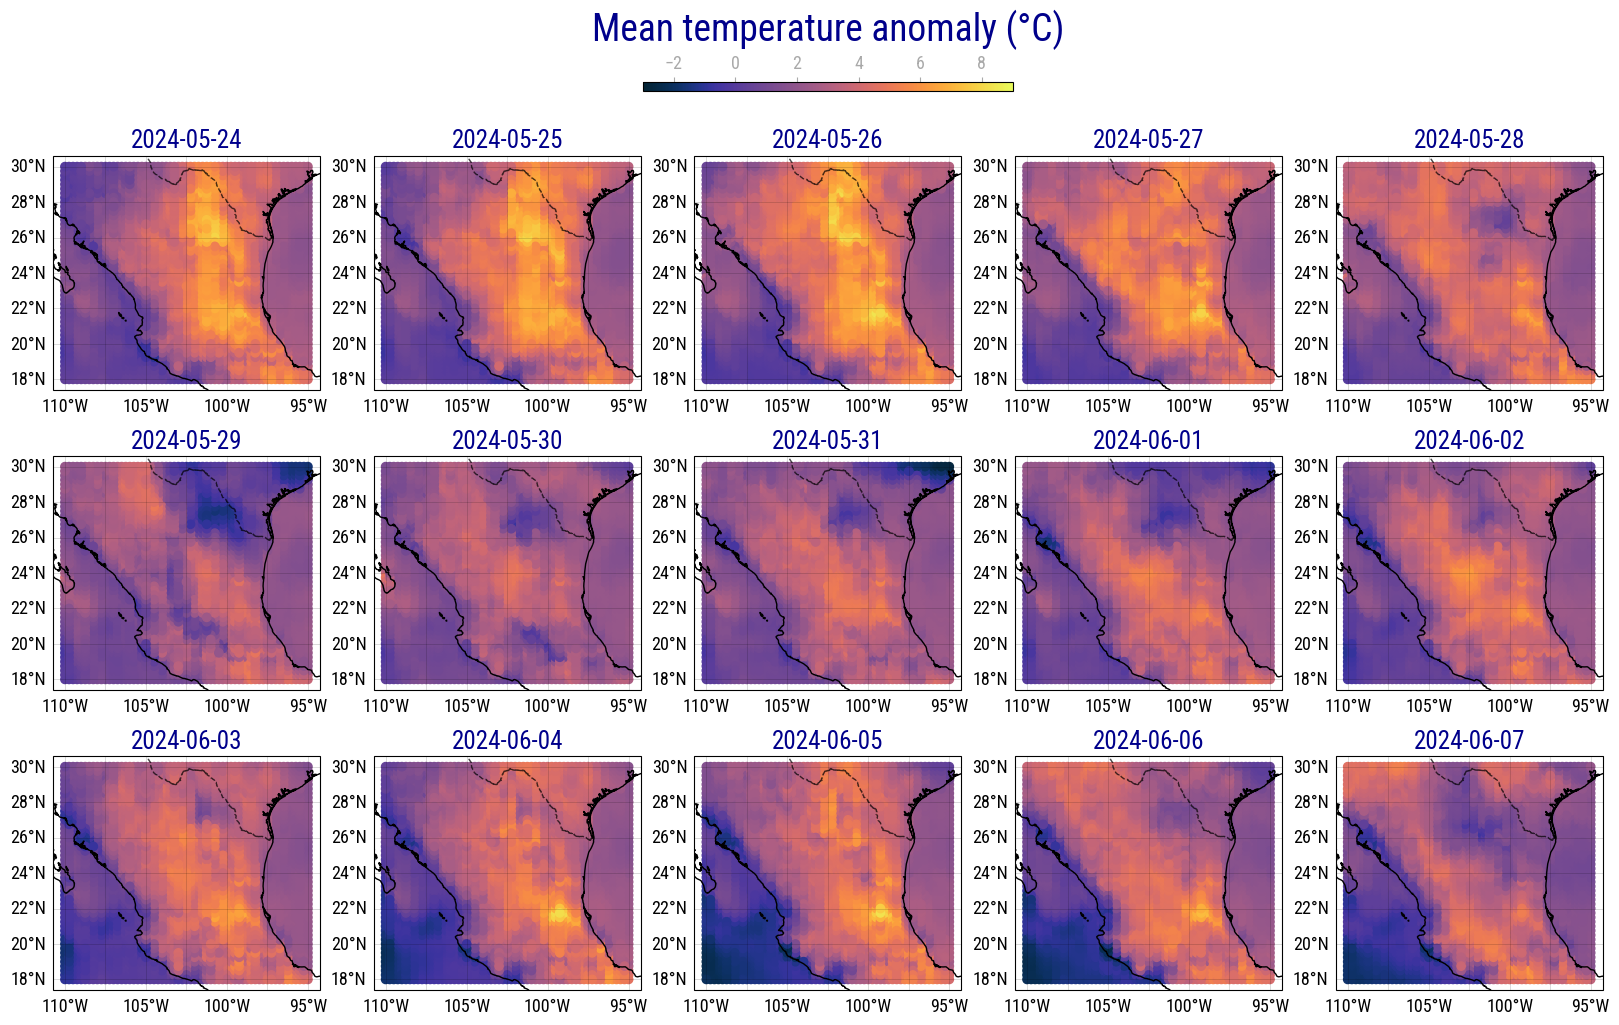

In [9]:
# 2.2 Calculate and show anomaly

# # calculate mean climatology for the days surrounding the event date
# climatology_gdf_1991_2020_31d = calculate_mean_gdf(
#     gdf=climatology_gdf_1991_2020,
#     date_range=event_gdf['valid_time'].unique(),
#     padding=15,
#     value_col='t2m',
#     datetime_col='valid_time'
#     )

# calculate anomaly for the event period compared to the mean climatology
event_gdf_anomaly = calculate_anomaly(
    event_gdf=event_gdf,
    mean_climatology_gdf=mean_climatology_event,
    value_col='t2m',
    datetime_col='valid_time',
    calcation='subtract'
)

# plot anomaly
fig, axes = subplot_gdf(
    event_gdf_anomaly,
    datetime_col='valid_time',
    value_col='t2m',
    ncols=5,
    cmap=cmocean.cm.thermal,
    legend_title='Mean temperature anomaly (°C)'
)

In [10]:
# 2.2 d

# pick a single day and create a figure for the region picker
selected_date = datetime(2024,6,4)
img_base64 = get_base_fig(selected_date, event_gdf_anomaly, value_col='t2m')

# turn bbox into a string for the region picker
sbbox = ",".join(map(str, bbox))

# create params for region picker, includes bbox and image overlay of picked day
params = {
    "bbox": sbbox,
    "image": 'data:image/png;base64,'+img_base64    # image overlay needs the following prefix to work
}

# regiontype wraf for temperature, hydrobasin for precipitation
# select region (opens web browser)
result = select_region(regionType='wraf', params=params)
# interpret the result as JSON
data = json.loads(result)

# convert data to polygons and coordinates
polygons, coords = data_2_poly(data)

The region picker will shortly open in your web browser. Please select a region, close the browser tab and return to the notebook when done.
Region Picker started successfully for wraf:
Polling for region selection...
Region selection process done.
Received polygon data:
{"type":"FeatureCollection","features":[{"type":"Feature","properties":{"merge_key":"1"},"geometry":{"type":"Polygon","coordinates":[[[-104.292,22.2917],[-104.208,22.2917],[-104.208,22.3333],[-104.042,22.3333],[-104.042,22.375],[-103.958,22.375],[-103.958,22.4583],[-103.917,22.4583],[-103.917,22.5],[-103.958,22.5],[-103.958,22.5417],[-104,22.5417],[-104,22.7917],[-103.958,22.7917],[-103.958,22.75],[-103.792,22.75],[-103.792,22.5833],[-103.833,22.5833],[-103.833,22.5],[-103.875,22.5],[-103.875,22.2083],[-103.833,22.2083],[-103.833,22.3333],[-103.792,22.3333],[-103.792,22.5417],[-103.75,22.5417],[-103.75,22.625],[-103.708,22.625],[-103.708,22.5833],[-103.625,22.5833],[-103.625,22.4583],[-103.667,22.4583],[-103.667,22.125

c:\Python310\lib\site-packages\xarray\coding\times.py:213: SerializationWarning: Ambiguous reference date string: 1-1-1 0:0:0. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1 0:0:0). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  ref_date = _ensure_padded_year(ref_date)
C:\Users\jasper\AppData\Local\Temp\ipykernel_18316\1725737792.py:3: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")


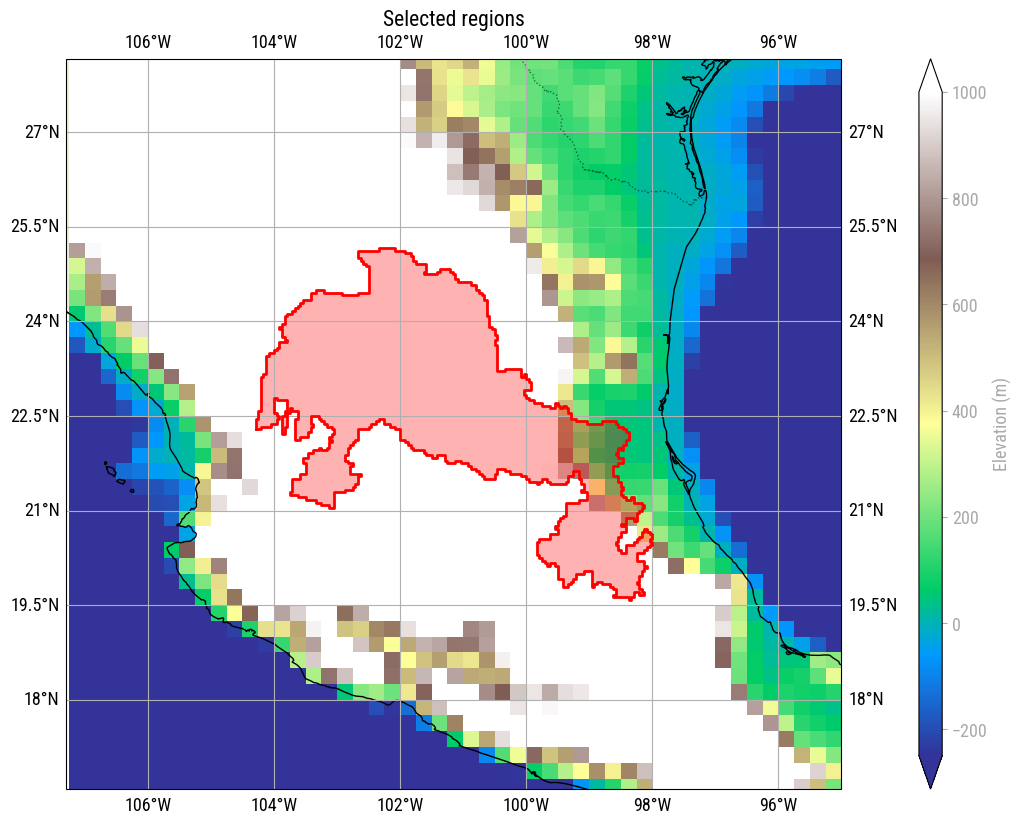

In [11]:
#2.2 d/e
# load elevation data from a NetCDF file
elevation_nc = xr.open_dataset("../data/elev.0.25-deg.nc")
elevation = wrap_lon(elevation_nc)['data']

# plot polygon, elevation is optional
fig, ax = plot_poly(polygons, coords, elevation=elevation)

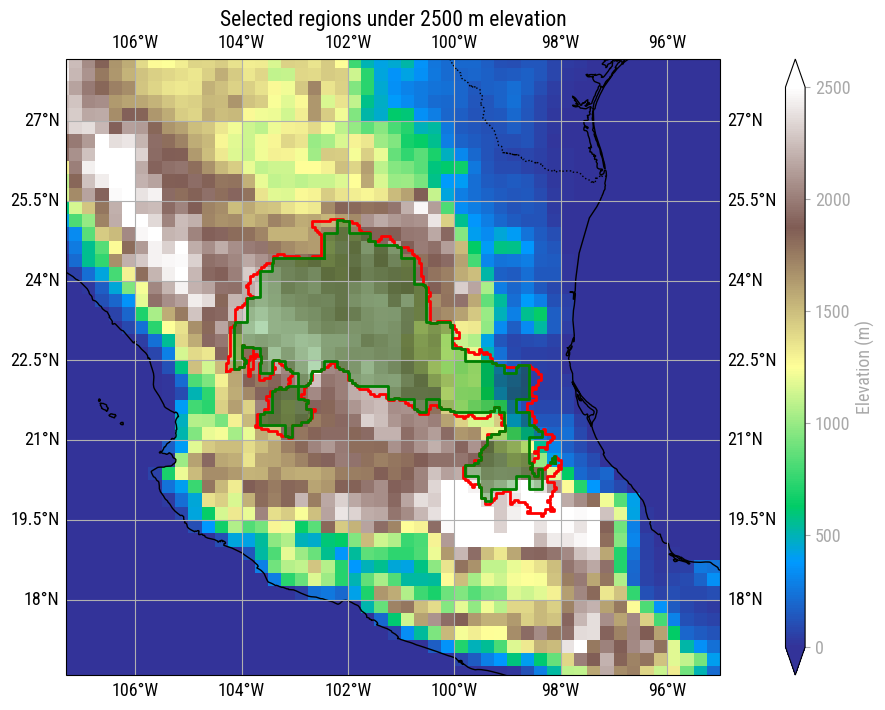

In [12]:
#2.2 e
# plot polygons based on selected region and elevation threshold
elevation_threshold = 2500  # meters
fig, ax, adjusted_polygons = elevation_region(data, polygons, elevation, elevation_threshold)

In [13]:
# 2.3
# write polygons to a shapefile
multipoly = unary_union(adjusted_polygons)
studyregion_gdf = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[multipoly])    # is this using the correct CRS?
studyregion_gdf.to_file("../data/sf_studyregion.shp")

polygons_gdf = gpd.GeoDataFrame(geometry=polygons, crs="EPSG:4326")
polygons_gdf.to_file("../data/sf_polygons.shp")

In [14]:
# 2.4
# average the study domain
# intersect for study domain
climatology_2_event_gdf_intersected = gpd.overlay(climatology_gdf_1950_event, polygons_gdf, how='intersection')
mean_climatology_2_event_gdf_intersected = climatology_2_event_gdf_intersected.groupby("valid_time")["t2m"].mean().reset_index()
mean_climatology_2_event_gdf_intersected.to_xarray().to_netcdf("../data/mean_temperature.nc")
mean_climatology_2_event_gdf_intersected

,valid_time,t2m
0,1951-01-01,13.174224
1,1951-01-02,13.901039
2,1951-01-03,12.070193
3,1951-01-04,11.682031
4,1951-01-05,13.174847
...,...,...
26817,2024-06-03,27.074383
26818,2024-06-04,27.262646
26819,2024-06-05,27.086111
26820,2024-06-06,26.869633


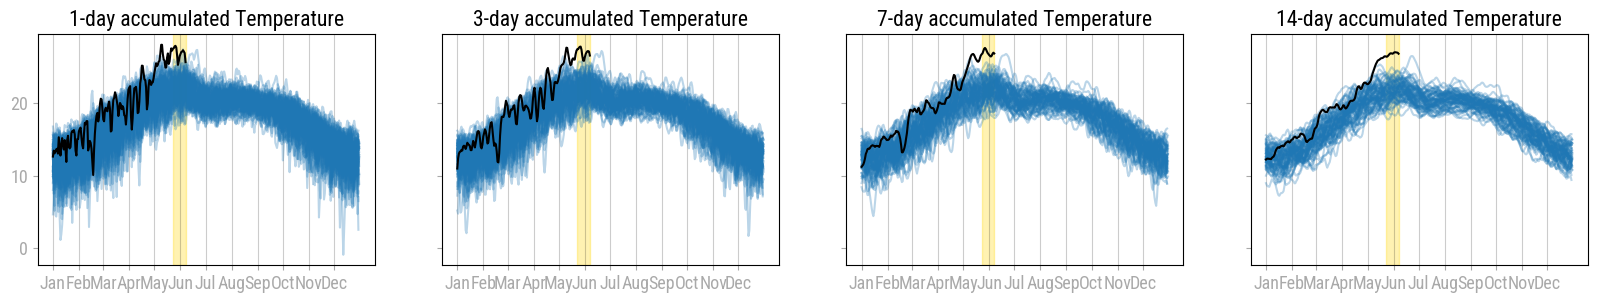

In [15]:
# 2.5

# choose windows
# temperature (t2m): days = [1, 3, 7, 14]
# preticipation (tp): days = [1, 3, 5, 10]
# else days = [1, 3, 5, 11]

# creating labels and intersecting with polygons
labelticks = pd.date_range("2000-01-01", "2000-12-31", freq="MS").dayofyear
labels = pd.date_range("2000-01-01", "2000-12-31", freq="MS").strftime("%b")

# temperature rolling days
days = [1, 3, 7, 14]

# create a list of rolled days for the climatology
rolled_data_list = [n_day_accumulations_gdf(gdf = mean_climatology_2_event_gdf_intersected, value_col='t2m', datetime_col='valid_time', padding=d, centering=False, method='mean') for d in days]

# plot the rolled days
fig, axs = plot_n_day_accumulations(
    rolled_data_list, 
    value_col='t2m',
    parameter="Temperature",
    event_date=event_date,
    labelticks=labelticks,
    labels=labels,
    days=days,
    ylimit=None
)

In [16]:
# 2.6
# create 30-day smoothed climatology for 1991-2020 for the study domain
climatology_1991_2020_poly = sliding_stat_by_dayofyear(climatology_2_event_gdf_intersected, value_col='t2m', padding=15)
# turn result back into a geodataframe
climatology_event_poly = gpd.GeoDataFrame(climatology_1991_2020_poly, geometry=gpd.points_from_xy(climatology_1991_2020_poly.longitude, climatology_1991_2020_poly.latitude), crs=event_gdf.crs)
# turn doy back into valid_time
climatology_event_poly['valid_time'] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(climatology_event_poly['doy'] - 1, unit='D')
# average over the area
climatology_event_poly_area = climatology_event_poly.groupby("valid_time")["t2m"].mean().reset_index()
climatology_event_poly_area

c:\Python310\lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,valid_time,t2m
0,2024-01-01,12.499087
1,2024-01-02,12.476962
2,2024-01-03,12.465965
3,2024-01-04,12.452852
4,2024-01-05,12.447639
...,...,...
360,2024-12-26,12.651916
361,2024-12-27,12.619959
362,2024-12-28,12.585445
363,2024-12-29,12.542884


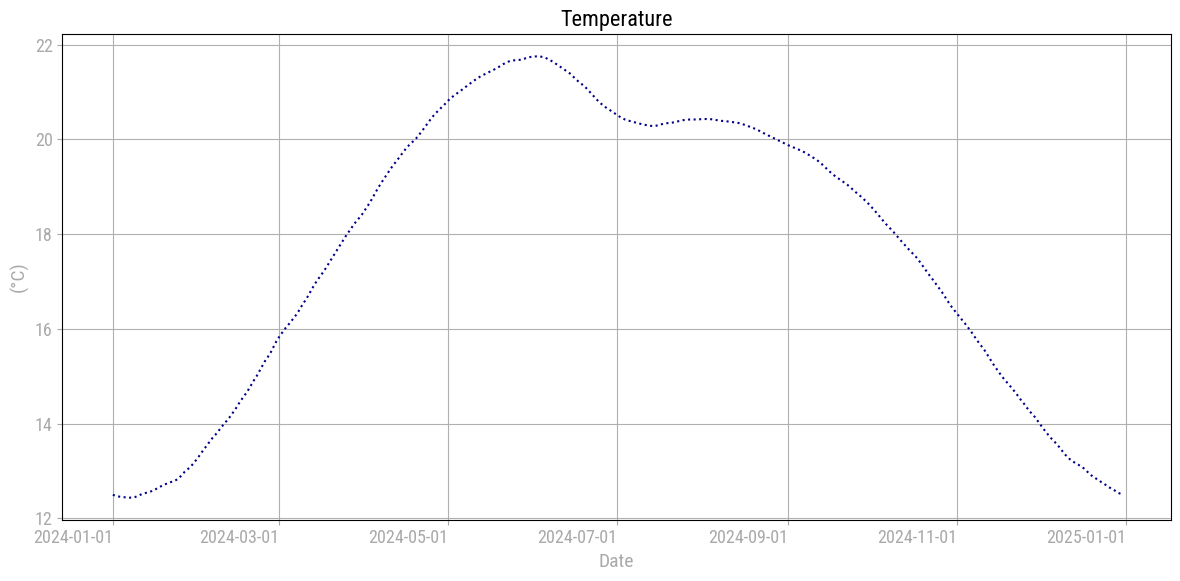

In [17]:
# 2.6
plot_timeserie(data=climatology_event_poly_area, value_col='t2m', title='Temperature', x_label='Date', y_label='(°C)', line_style=':')

2.7 Decide on the temporal extent using Step 2.2 and the following considerations:

    a. As much related to impacts as possible
        i. e.g. TXx max Temperature 1-day (outdoor workers), 
           T3x mean Temperature 3-day (people indoors)
        ii. e.g. flooding: precipitation averaged over duration 
            or over response time basin
        iii. e.g. drought: precipitation values (or soil moisture) 
             averaged over several months or multiple rainy seasons

    b. Seasonality
        i. OPTIONAL: Use information from literature review 
           (see also Sec. 6a.), specifically for information on seasonality, 
           that can feed into the choice of event definition. 
        ii. Make use of seasonal cycle plot 
        iii. Restrict to some months if necessary, if event occurred 
             outside of the usual season or a change in seasonality is suspected, 
             e.g. May-June maximum 4-day precipitation
        iv. Potentially take temperature anomalies rather than absolute values 
            if averaging over months where the seasonal cycle is in transition 
            between peaks and troughs

    c. Make use of the plots created in Step 2.5.

2.8 Make a final decision on the event definition. Update the output table 
    in the tables document (apart from the last row on return period)

    a. Write down in the Jupyter Notebook the factors that informed the specific 
       event definition. Use the following considerations as a guide to single out 
       which aspect of the multifaceted nature of the extreme is chosen for emphasis 
       and communication.  

        i. Variable: (Tmax or Tmin or Tmean – were the daily maxima or the high 
           nighttime minima or both the most defining for the heat event?)

        ii. Timing: Is it the early-season onset of the event that made it anomalous 
            (only) for the time of year, giving locals little time to adjust?

        iii. Seasonality: Is it specific for a single season only, in case of multiple 
             peaks in the seasonal cycle?

        iv. Duration: Is it daily record-breaking extremes that will dominate headlines 
            or the long persistence of heat that will also impact indoor conditions, 
            drought or fire weather and be felt more than one day of exceptional heat etc.?

        v. Spatial: Is the large spatial extent of the event particularly noteworthy 
           over other factors and in comparison to previous similar events in the region? 
           Is it that the event location coincides with a densely populated area that 
           makes it particularly noteworthy?

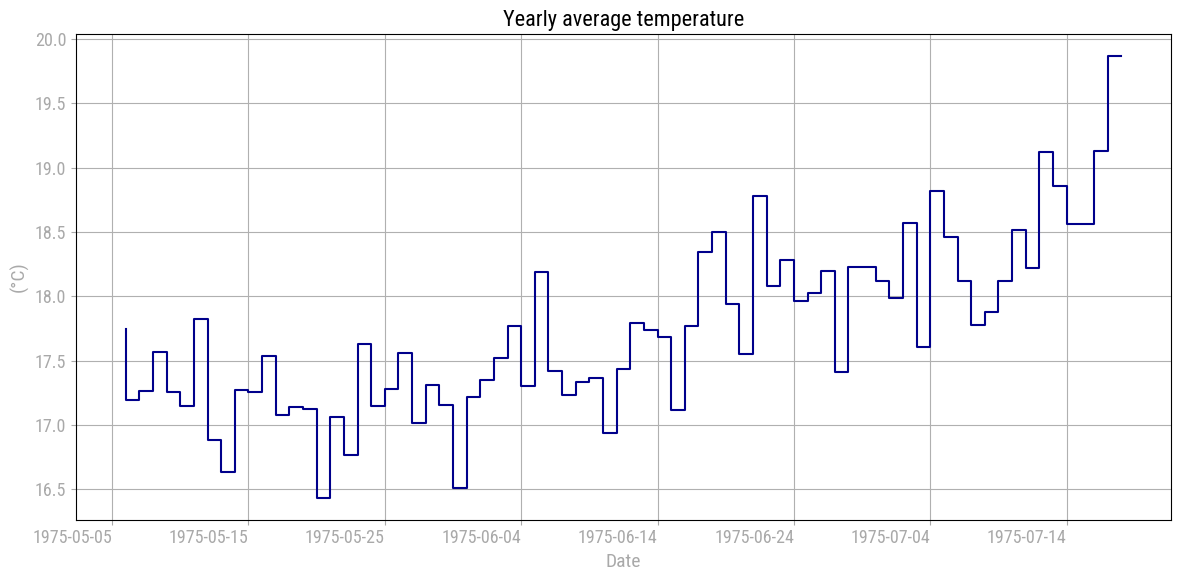

In [18]:
#2.9
mean_climatology_2_event_gdf_intersected['valid_time'] = pd.to_datetime(mean_climatology_2_event_gdf_intersected['valid_time'])

# Extract year
mean_climatology_2_event_gdf_intersected['year'] = mean_climatology_2_event_gdf_intersected['valid_time'].dt.year

# Calculate yearly average
yearly_avg = mean_climatology_2_event_gdf_intersected.groupby('year')['t2m'].mean().reset_index()

# plot the time series
plot_timeserie(data=yearly_avg, value_col='t2m', datetime_col='year', title='Yearly average temperature', x_label='Date', y_label='(°C)', line_style='-', draw_style='steps')

In [19]:
#2.10
# read station data time series from .xls
#xls_station_data = pd.ExcelFile("../data/example.xlsx")
#print(xls_station_data.sheet_names)   # list available sheets
#xls_station_data_sheet1 = pd.read_excel(xls_station_data, "Sheet1")
#xls_station_data_sheet2 = pd.read_excel(xls_station_data, "Sheet2")

c:\Python310\lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Text(0.5, 1.0, 'Mean temperature anomaly 2024-06-04')

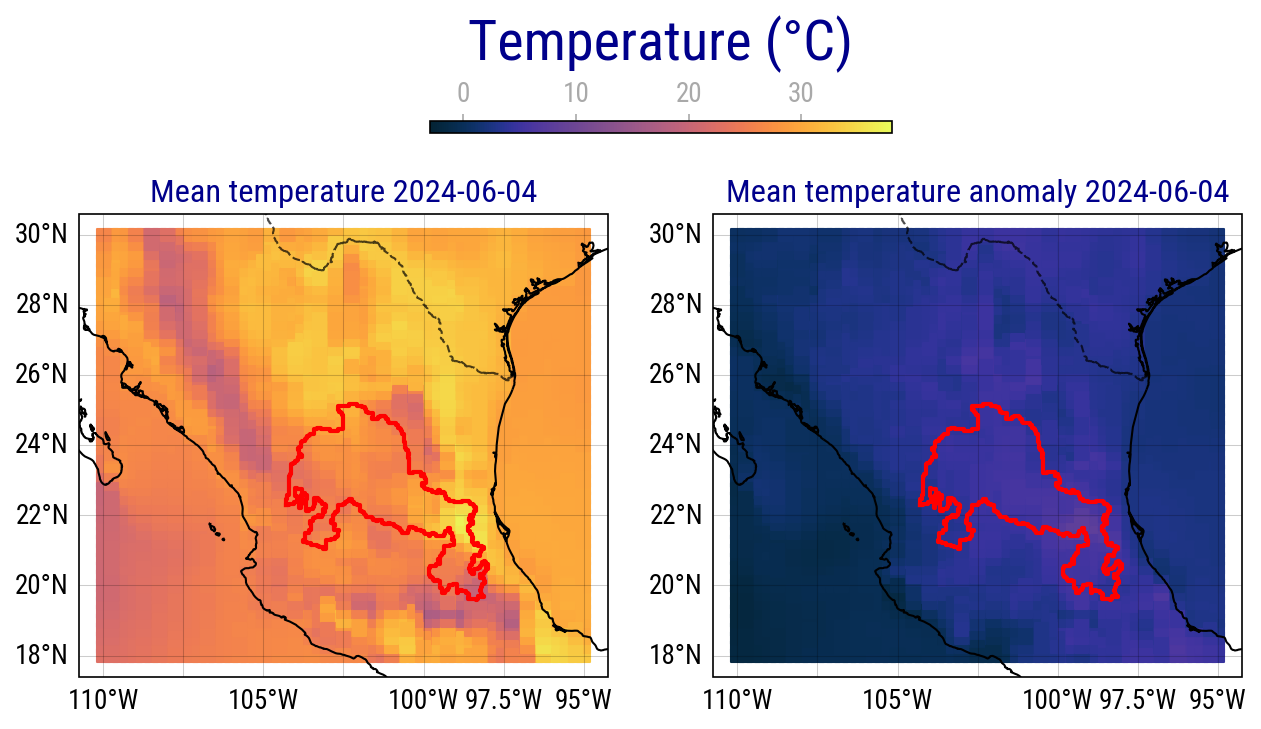

In [20]:
#2.11 - Making it work with subplot_gdf function from our library
# this is intended to be a figure that will be published on the factsheet, so it should be the larger domain, that the user has specified earlier on, which incorporates the study domain which should be outlined
selected_date = datetime(2024,6,4)

# so this is just the a single day of the event with its anomaly
gdf_selected_intersect = event_gdf[(event_gdf['valid_time'] >= selected_date) & (event_gdf['valid_time'] <= selected_date)] #.overlay(poly_gdf, how='intersection')
gdf_select_intersect_anomoly = event_gdf_anomaly[(event_gdf_anomaly['valid_time'] >= selected_date) & (event_gdf_anomaly['valid_time'] <= selected_date)] #.overlay(poly_gdf, how='intersection')

# we cheat this for now because the subplots are split based on date, so we just move the anomoly to the next day
gdf_select_intersect_anomoly['valid_time'] = pd.to_datetime(gdf_select_intersect_anomoly["valid_time"]) + pd.Timedelta(days=1)

gdf_selected_intersect = pd.concat([gdf_selected_intersect, gdf_select_intersect_anomoly], ignore_index=True)

minx, miny, maxx, maxy = gdf_selected_intersect.total_bounds
dx = (maxx - minx) * 0.5   # 10% of width
dy = (maxy - miny) * 0.5   # 10% of height
expanded_extent = [minx - dx, maxx + dx, miny - dy, maxy + dy]

# create subplot using first gdf
fig, axes = subplot_gdf(
    gdf_selected_intersect,
    #title=f"Mean temperature {event_date.strftime('%Y-%m-%d')}",
    legend_title="Temperature (°C)",
    value_col='t2m',
    cmap=cmocean.cm.thermal,
    ncols=2,
    figsize=(10,10),
    flatten_empty_plots=False,
    #extends=expanded_extent,
    marker='s',
    dpi=150,
    polygons=polygons
)
axes[0].set_title(f"Mean temperature {selected_date.strftime('%Y-%m-%d')}")
axes[1].set_title(f"Mean temperature anomaly {selected_date.strftime('%Y-%m-%d')}")

In [21]:
#2.15
mean_climatology_event_choice = gpd.GeoDataFrame(mean_climatology_1991_2020, geometry=gpd.points_from_xy(mean_climatology_1991_2020.longitude, mean_climatology_1991_2020.latitude), crs=event_gdf.crs)
mean_climatology_event_choice['valid_time'] = pd.to_datetime('2024', format='%Y') + pd.to_timedelta(mean_climatology_event_choice['doy'] - 1, unit='D')

year = 2024
month = 6  # June

# Filter for the chosen month and year
month_gdf = mean_climatology_event_choice[(mean_climatology_event_choice['valid_time'].dt.year == year) & (mean_climatology_event_choice['valid_time'].dt.month == month)]

# Group by location (longitude, latitude, geometry) and calculate mean temperature
monthly_avg_gdf = month_gdf.groupby(['longitude', 'latitude', 'geometry'], as_index=False)['t2m'].mean()
monthly_avg_gdf

,longitude,latitude,geometry,t2m
0,-110.0,18.00,POINT (-110 18),24.998846
1,-110.0,18.25,POINT (-110 18.25),24.833368
2,-110.0,18.50,POINT (-110 18.5),24.679853
3,-110.0,18.75,POINT (-110 18.75),24.503157
4,-110.0,19.00,POINT (-110 19),24.322914
...,...,...,...,...
2984,-95.0,29.00,POINT (-95 29),27.181828
2985,-95.0,29.25,POINT (-95 29.25),27.259731
2986,-95.0,29.50,POINT (-95 29.5),27.403139
2987,-95.0,29.75,POINT (-95 29.75),27.417582


In [22]:
#2.15
gdf_monthly_avg_gdf = gpd.GeoDataFrame(
    monthly_avg_gdf,  # your original DataFrame
    geometry=gpd.points_from_xy(monthly_avg_gdf.longitude, monthly_avg_gdf.latitude),
    crs=event_gdf.crs  
)

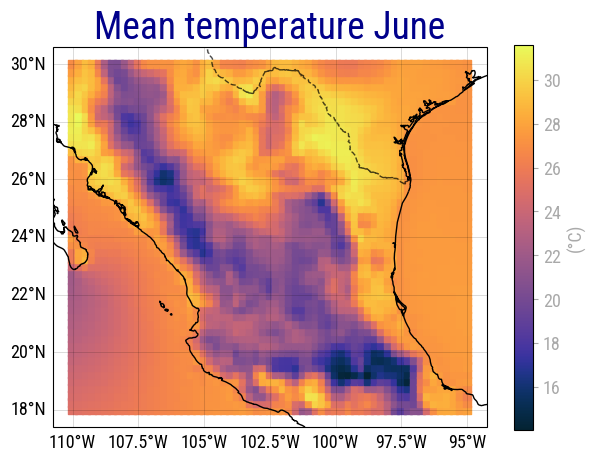

In [23]:
#2.15
fig, ax = plot_gdf(
    gdf_monthly_avg_gdf,
    title=f"Mean temperature June",
    legend_title="(°C)",
    value_col='t2m',
    cmap=cmocean.cm.thermal
)